<h1> Ana Petrovic - Masinsko ucenje projekat </h1>

In [1]:
import time
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm 
import pylab as py 
import math
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score,cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
data = pd.read_csv('housing.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
data.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [7]:
nan_counts_per_predictor = data.isna().sum()
pd.DataFrame({
    'Predictor': nan_counts_per_predictor.index,
    'NaN Count': nan_counts_per_predictor.values
})

,Predictor,NaN Count
0,longitude,0
1,latitude,0
2,housing_median_age,0
3,total_rooms,0
4,total_bedrooms,207
5,population,0
6,households,0
7,median_income,0
8,median_house_value,0
9,ocean_proximity,0


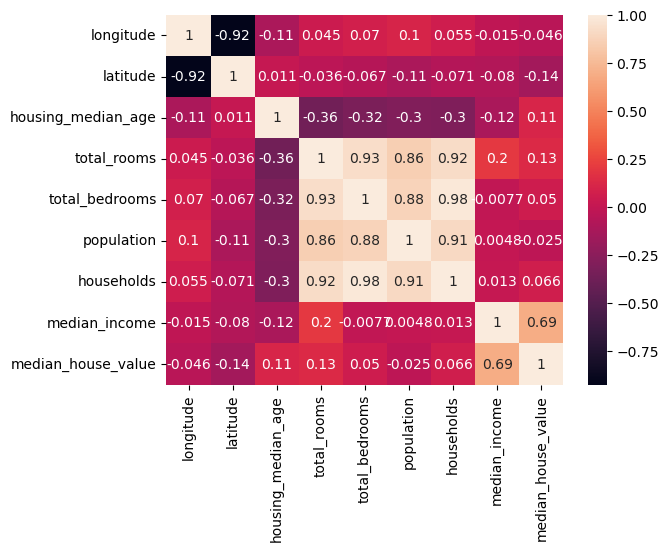

In [8]:
correlation_matrix = data.loc[:, data.columns != 'ocean_proximity'].corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [9]:
for i in range(0,207):
    households = data[data['total_bedrooms'].isna()].iloc[0]['households']
    
    df_copy = data.copy()
    df_copy['difference'] = abs(df_copy['households'] - households)
    df_sorted = df_copy.sort_values(by='difference')

    data.loc[data[data['total_bedrooms'].isna()].iloc[0].name,'total_bedrooms'] = df_sorted.head(20)['total_bedrooms'].median()

In [10]:
nan_counts_per_predictor = data.isna().sum()
pd.DataFrame({
    'Predictor': nan_counts_per_predictor.index,
    'NaN Count': nan_counts_per_predictor.values
})

,Predictor,NaN Count
0,longitude,0
1,latitude,0
2,housing_median_age,0
3,total_rooms,0
4,total_bedrooms,0
5,population,0
6,households,0
7,median_income,0
8,median_house_value,0
9,ocean_proximity,0


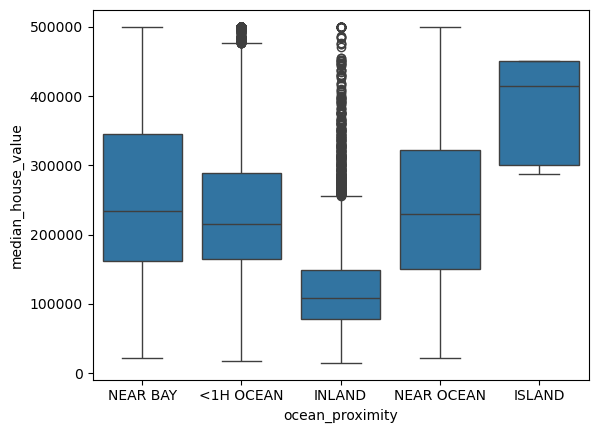

In [11]:
sns.boxplot(x='ocean_proximity', y='median_house_value', data=data)
plt.show()

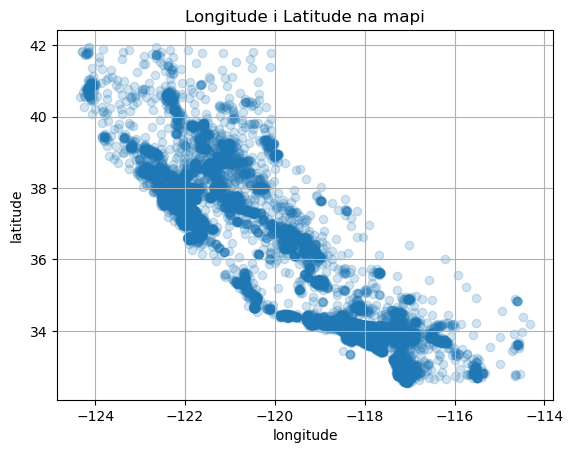

In [12]:
plt.scatter(data['longitude'], data['latitude'], alpha=0.2)
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('Longitude i Latitude na mapi')
plt.grid()

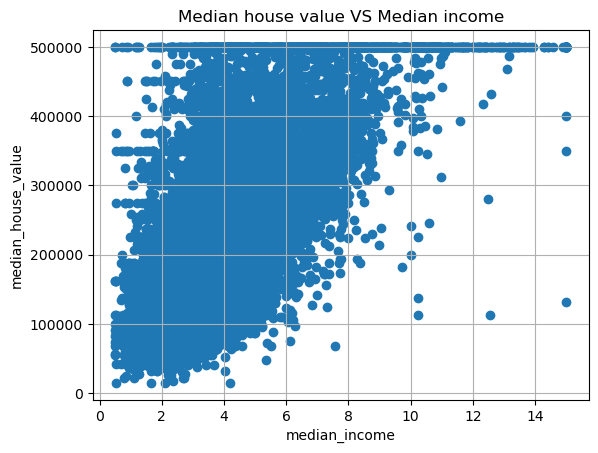

In [13]:
plt.scatter(data['median_income'], data['median_house_value'])
plt.xlabel('median_income')
plt.ylabel('median_house_value')
plt.title('Median house value VS Median income')
plt.grid()

In [14]:
data.ocean_proximity.value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [15]:
data.loc[(data['latitude'] > 38.2) & (data['ocean_proximity']=='NEAR OCEAN'), 'ocean_proximity'] = 'NEAR OCEAN NORTH'
data.loc[(data['latitude'] > 38.2) & (data['ocean_proximity']=='<1H OCEAN'), 'ocean_proximity'] = '<1H OCEAN NORTH'

In [16]:
data.ocean_proximity.value_counts()

<1H OCEAN           8740
INLAND              6551
NEAR OCEAN          2531
NEAR BAY            2290
<1H OCEAN NORTH      396
NEAR OCEAN NORTH     127
ISLAND                 5
Name: ocean_proximity, dtype: int64

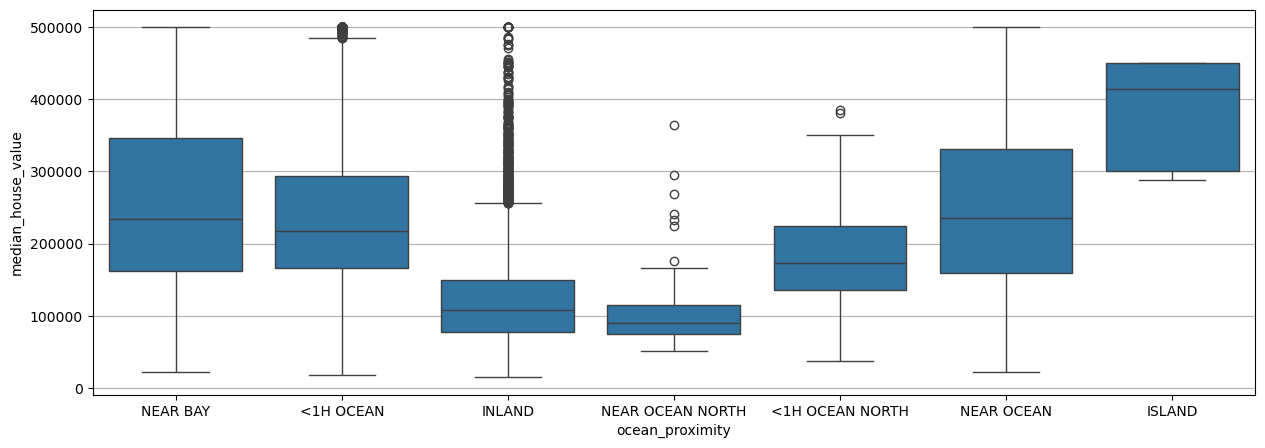

In [17]:
plt.figure(figsize=(15,5))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=data)
plt.grid(axis='y')
plt.show()

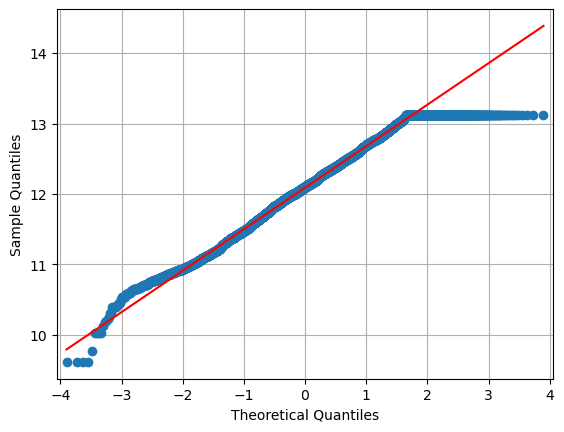

In [18]:
sm.qqplot(data['median_house_value'].astype(int).apply(np.log), line='q')
py.grid()
py.show()

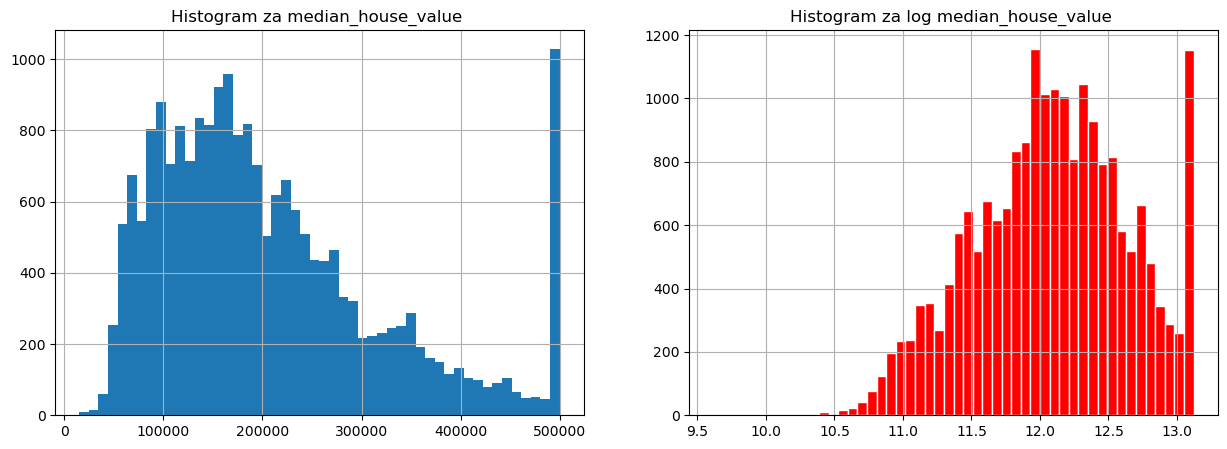

In [19]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,2)
plt.hist(data['median_house_value'].astype(int).apply(np.log), bins=50, color='red', edgecolor='white')
plt.grid()
plt.title('Histogram za log median_house_value ')
plt.subplot(1,2,1)
plt.hist(data['median_house_value'], bins=50)
plt.grid()
plt.title('Histogram za median_house_value ')
plt.show()

In [20]:
log_data = data.copy()
for feature in ['households', 'median_income', 'median_house_value', 'total_rooms', 'total_bedrooms', 'population']:
    log_data[feature] = log_data[feature].apply(np.log)
label_encoder = LabelEncoder()
log_data['ocean_proximity'] = label_encoder.fit_transform(log_data['ocean_proximity'])

In [21]:
log_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,6.779922,4.859812,5.774552,4.836282,2.119287,13.022764,4
1,-122.22,37.86,21.0,8.867709,7.008505,7.783641,7.037028,2.116424,12.789684,4
2,-122.24,37.85,52.0,7.290975,5.247024,6.206576,5.176150,1.982022,12.771671,4
3,-122.25,37.85,52.0,7.149917,5.459586,6.324359,5.389072,1.730434,12.740517,4
4,-122.25,37.85,52.0,7.394493,5.634790,6.336826,5.556828,1.347086,12.743151,4


In [22]:
y = log_data['median_house_value']
x = log_data.drop(columns=['median_house_value'])
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

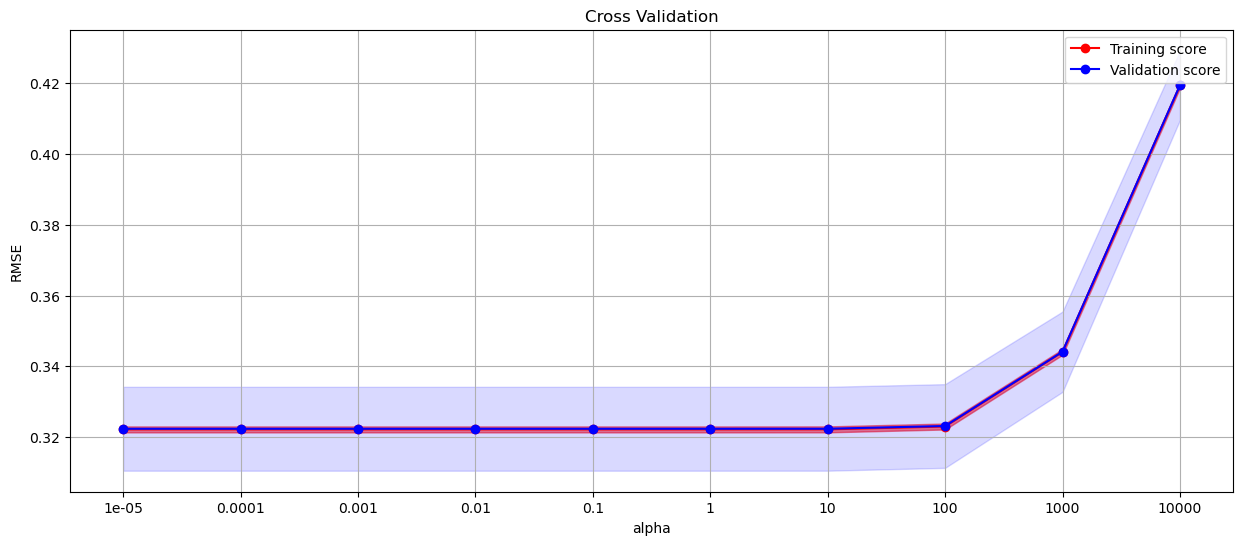

In [23]:
mean_val = list()
mean_train = list()
std_val = list()
std_train = list()
for alpha in [10**i for i in range(-5,5)]:
    clf = Ridge(alpha=alpha)
    clf.fit(X_train,y_train)
    score = cross_validate(clf, X_train, y_train, cv=15, return_train_score=True, scoring='neg_root_mean_squared_error')
    mean_val += [np.mean(score['test_score'])*(-1)]
    mean_train += [np.mean(score['train_score'])*(-1)]
    std_val += [np.std(score['test_score'])]
    std_train += [np.std(score['train_score'])]
    
plt.figure(figsize=(15, 6))
plt.plot(range(10), mean_train, label='Training score', color='red', marker='o')
plt.fill_between(range(10), np.array(mean_train) - np.array(std_train), np.array(mean_train) + np.array(std_train), alpha=0.5, color='red')

plt.plot(range(10), mean_val, label='Validation score', color='blue', marker='o')
plt.fill_between(range(10), np.array(mean_val) - np.array(std_val), np.array(mean_val) + np.array(std_val), alpha=0.15, color='blue')
plt.xticks(range(10), [10**i for i in range(-5,5)])
plt.title('Cross Validation')
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.grid()
plt.legend()
plt.show()

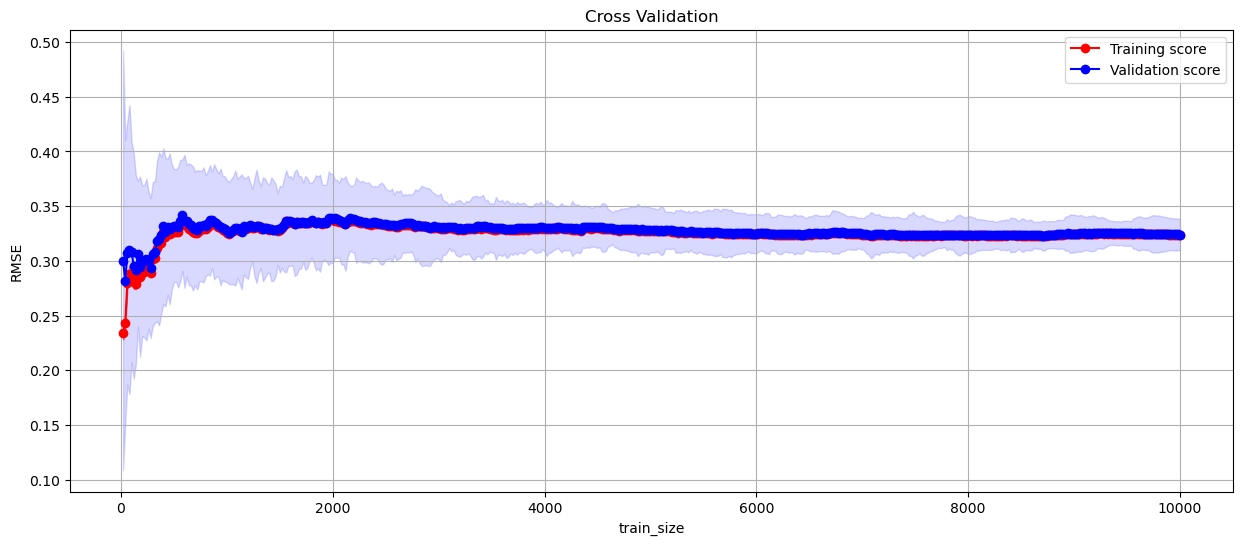

In [24]:
mean_val = list()
mean_train = list()
std_val = list()
std_train = list()

for i in range(20,10001,20):
    X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=i, random_state=42)
    clf = Ridge(alpha=1)
    clf.fit(X_train,y_train)
    score = cross_validate(clf, X_train, y_train, cv=20, return_train_score=True, scoring='neg_root_mean_squared_error')
    mean_val += [np.mean(score['test_score'])*(-1)]
    mean_train += [np.mean(score['train_score'])*(-1)]
    std_val += [np.std(score['test_score'])]
    std_train += [np.std(score['train_score'])]
    
plt.figure(figsize=(15, 6))
plt.plot(range(20,10001,20), mean_train, label='Training score', color='red', marker='o')
plt.fill_between(range(20,10001,20), np.array(mean_train) - np.array(std_train), np.array(mean_train) + np.array(std_train), alpha=0.5, color='red')

plt.plot(range(20,10001,20), mean_val, label='Validation score', color='blue', marker='o')
plt.fill_between(range(20,10001,20), np.array(mean_val) - np.array(std_val), np.array(mean_val) + np.array(std_val), alpha=0.15, color='blue')
plt.title('Cross Validation')
plt.xlabel('train_size')
plt.ylabel('RMSE')
plt.grid()
plt.legend()
plt.show()

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
clf = Ridge(alpha=1)
clf.fit(X_train,y_train)
y_predict = clf.predict(X_test)
Ridge_RMSE = np.sqrt(mean_squared_error(y_test,y_predict))

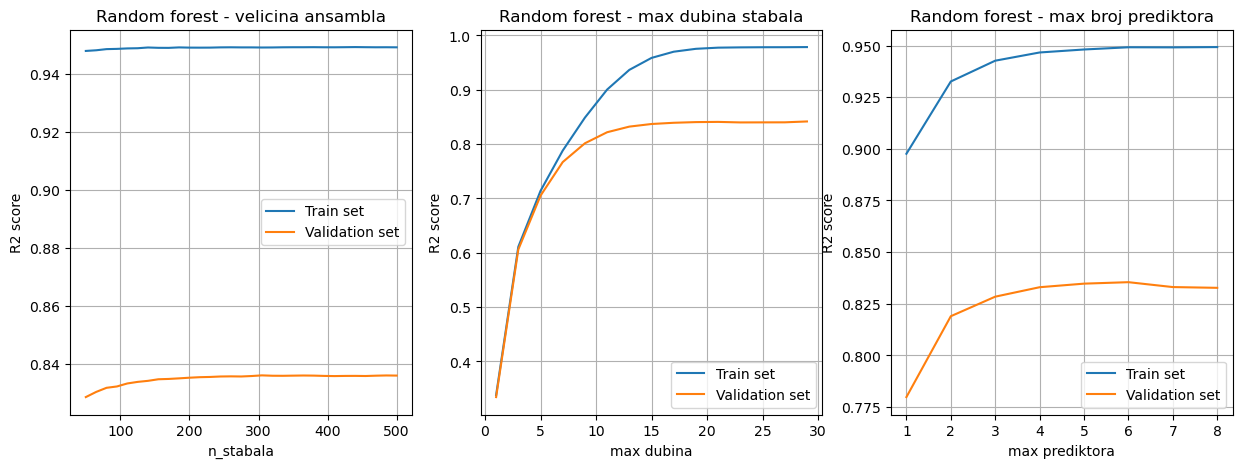

In [46]:
ensemble_sizes = np.arange(50,515,15)
tree_sizes = np.arange(1,30,2)
max_features = np.arange(1,9)

plt.figure(figsize=(15, 5));
accuracy_train = list()
accuracy_val = list()

for n_estimators in ensemble_sizes:
    RF_model = RandomForestRegressor(n_estimators=n_estimators, max_depth=14, max_features=6, random_state=42, oob_score=True)
    RF_model.fit(X_train, y_train)
    accuracy_train += [RF_model.score(X_train,y_train)]
    accuracy_val += [RF_model.oob_score_]
plt.subplot(1, 3, 1)
plt.plot(ensemble_sizes, accuracy_train, label='Train set')
plt.plot(ensemble_sizes, accuracy_val, label='Validation set')
plt.title('Random forest - velicina ansambla')
plt.xlabel('n_stabala')
plt.ylabel('R2 score')
plt.grid()
plt.legend()

accuracy_train = list()
accuracy_val = list()
for max_depth in tree_sizes:
    RF_model = RandomForestRegressor(n_estimators=205, max_depth=max_depth, max_features=6, random_state=42, oob_score=True)
    RF_model.fit(X_train, y_train)
    accuracy_train += [RF_model.score(X_train,y_train)]
    accuracy_val += [RF_model.oob_score_]
plt.subplot(1, 3, 2)
plt.plot(tree_sizes, accuracy_train, label='Train set')
plt.plot(tree_sizes, accuracy_val, label='Validation set')
plt.title('Random forest - max dubina stabala')
plt.xlabel('max dubina')
plt.ylabel('R2 score')
plt.grid()
plt.legend()

accuracy_train = list()
accuracy_val = list()
for features in max_features:
    RF_model = RandomForestRegressor(n_estimators=205, max_depth=14, max_features=features, random_state=42, oob_score=True)
    RF_model.fit(X_train, y_train)
    accuracy_train += [RF_model.score(X_train,y_train)]
    accuracy_val += [RF_model.oob_score_]
plt.subplot(1, 3, 3)
plt.plot(max_features, accuracy_train, label='Train set')
plt.plot(max_features, accuracy_val, label='Validation set')
plt.title('Random forest - max broj prediktora')
plt.xlabel('max prediktora')
plt.ylabel('R2 score')
plt.grid()
plt.legend()
plt.show()

In [27]:
RF_model = RandomForestRegressor(n_estimators=250, max_depth=14, max_features=6, random_state=42, oob_score=True)
RF_model.fit(X_train, y_train)
y_predict = RF_model.predict(X_test)
RF_rmse = np.sqrt(mean_squared_error(y_test,y_predict))

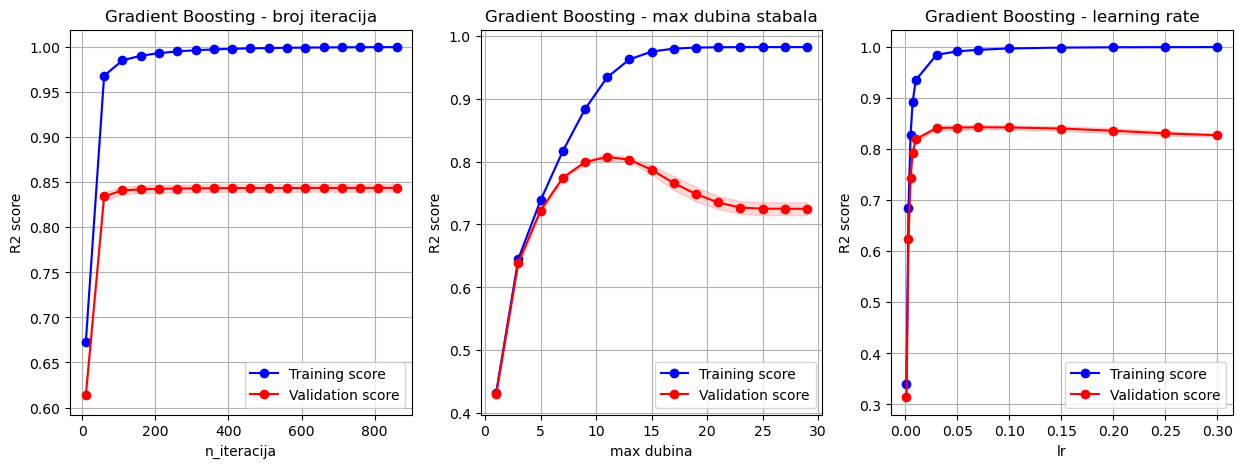

In [47]:
ensemble_sizes = np.arange(10,900,50)
tree_sizes = np.arange(1,30,2)
learning_rates = [0.001, 0.003, 0.005, 0.007, 0.01, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25, 0.3]
            
plt.figure(figsize=(15, 5));

mean_val = list()
mean_train = list()
std_val = list()
std_train = list()
for n_estimators in ensemble_sizes:
    GB_model = GradientBoostingRegressor(n_estimators=n_estimators, max_depth=10, learning_rate=0.07, random_state=42)
    score = cross_validate(GB_model, X_train, y_train, cv=5, return_train_score=True)

    mean_val += [np.mean(score['test_score'])]
    mean_train += [np.mean(score['train_score'])]
    std_val += [np.std(score['test_score'])]
    std_train += [np.std(score['train_score'])]
a = mean_val 
plt.subplot(1, 3, 1)
plt.plot(ensemble_sizes, mean_train, label='Training score', color='blue', marker='o')
plt.fill_between(ensemble_sizes, np.array(mean_train) - np.array(std_train), np.array(mean_train) + np.array(std_train), alpha=0.15, color='blue')
plt.plot(ensemble_sizes, mean_val, label='Validation score', color='red', marker='o')
plt.fill_between(ensemble_sizes, np.array(mean_val) - np.array(std_val), np.array(mean_val) + np.array(std_val), alpha=0.15, color='red')
plt.title('Gradient Boosting - broj iteracija')
plt.xlabel('n_iteracija')
plt.ylabel('R2 score')
plt.grid()
plt.legend()

mean_val = list()
mean_train = list()
std_val = list()
std_train = list()
for max_depth in tree_sizes:
    GB_model = GradientBoostingRegressor(n_estimators= 200, max_depth=max_depth, learning_rate=0.01, random_state=42)
    score = cross_validate(GB_model, X_train, y_train, cv=5, return_train_score=True)
    mean_val += [np.mean(score['test_score'])]
    mean_train += [np.mean(score['train_score'])]
    std_val += [np.std(score['test_score'])]
    std_train += [np.std(score['train_score'])]
plt.subplot(1, 3, 2)
plt.plot(tree_sizes, mean_train, label='Training score', color='blue', marker='o')
plt.fill_between(tree_sizes, np.array(mean_train) - np.array(std_train), np.array(mean_train) + np.array(std_train), alpha=0.15, color='blue')
plt.plot(tree_sizes, mean_val, label='Validation score', color='red', marker='o')
plt.fill_between(tree_sizes, np.array(mean_val) - np.array(std_val), np.array(mean_val) + np.array(std_val), alpha=0.15, color='red')
plt.title('Gradient Boosting - max dubina stabala')
plt.xlabel('max dubina')
plt.ylabel('R2 score')
plt.grid()
plt.legend()

mean_val = list()
mean_train = list()
std_val = list()
std_train = list()
for rate in learning_rates:
    GB_model = GradientBoostingRegressor(n_estimators= 250, max_depth=10, learning_rate=rate, random_state=42)
    score = cross_validate(GB_model, X_train, y_train, cv=5, return_train_score=True)
    mean_val += [np.mean(score['test_score'])]
    mean_train += [np.mean(score['train_score'])]
    std_val += [np.std(score['test_score'])]
    std_train += [np.std(score['train_score'])]
plt.subplot(1, 3, 3)
plt.plot(learning_rates, mean_train, label='Training score', color='blue', marker='o')
plt.fill_between(learning_rates, np.array(mean_train) - np.array(std_train), np.array(mean_train) + np.array(std_train), alpha=0.15, color='blue')
plt.plot(learning_rates, mean_val, label='Validation score', color='red', marker='o')
plt.fill_between(learning_rates, np.array(mean_val) - np.array(std_val), np.array(mean_val) + np.array(std_val), alpha=0.15, color='red')
plt.title('Gradient Boosting - learning rate')
plt.xlabel('lr')
plt.ylabel('R2 score')
plt.grid()
plt.legend()
plt.show() 

In [29]:
GB_model = GradientBoostingRegressor(n_estimators= 250, max_depth=10, learning_rate=0.07, random_state=42)
GB_model.fit(X_train, y_train)
y_predict = GB_model.predict(X_test)
GB_rmse = np.sqrt(mean_squared_error(y_test,y_predict))

In [31]:
print(Ridge_RMSE, RF_rmse, GB_rmse)

0.33078191201760937 0.23283111876154355 0.2216512322207172
